In [1]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import koreanize_matplotlib
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import sklearn
sklearn.set_config(display='text')

나이브 베이즈(Naive Bayes)

확률 기반 머신러닝 분류 알고리즘으로 데이터를 나이브(단순)하고 독립적인 사건으로 가정하고 이 독립 사건들을 베이즈 이론에 대입시켜 가장 높은 확률의 레이블로 분류하는 알고리즘이다.  
https://ineed-coffee.github.io/posts/Naive-Bayesian/ 참조

`가우시안 나이브 베이즈(Gaussian Naive Bayes)`  
분류 특징들의 값이 정규(가우시안) 분포되어있다는 가정하에 조건부 확률을 계산하며 연속적인 성질이 있는 특성 데이터를 분류하는데 적합하다.

$$P(A|B)=\frac{P(B|A)P(A)}{P(B)}$$

P(A): 임의의 사건 A가 발생할 확률, 사전확률  
P(B): 임의의 사건 B가 발생할 확률  
P(A|B): 임의의 사건 B가 발생했을 때 임의의 사건 A가 발생할 확률, 사후확률  
P(B|A): 임의의 사건 A가 발생했을 때 임의의 사건 B가 발생할 확률
<br><br>
<img src="./naivebayes1.png" width="1500" />
<img src="./naivebayes2.png" width="1500" />
<img src="./naivebayes3.png" width="1600" />

가우시안 나이브 베이즈를 이용한 붓꽃(iris) 분류

사이킷런이 제공하는 iris 데이터셋을 활용해서 데이터의 특징에 따른 붓꽃의 종류를 구분한다.

In [2]:
# 사이킷런이 제공하는 iris 데이터를 불러오기 위해 import 한다.
from sklearn.datasets import load_iris

방법1  
`df['temp'] = dataset.target`    
`df['target'] = np.nan`    
`df['target'] = df['target'].astype(str)`  
`df.loc[df.temp == 0, 'target'] = 'setosa'`  
`df.loc[df.temp == 1, 'target'] = 'versicolor'`  
`df.loc[df.temp == 2, 'target'] = 'virginica'`  
`df.drop('temp', axis=1, inplace=True)`

방법2  
`df['temp'] = dataset.target`  
`df['target'] = df.temp.map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})`  
`df.drop('temp', axis=1, inplace=True)`

방법3  
`df['target'] = pd.Series(dataset.target).map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})`

In [3]:
dataset = load_iris() # 사이킷런에서 제공하는 iris 데이터셋을 불러온다.
# print(dataset)
# print(type(dataset))
# print(dataset.data) # 사이킷런이 제공하는 데이터셋에서 데이터(피쳐)만 얻어온다.
# print(dataset.feature_names) # 사이킷런이 제공하는 데이터셋에서 데이터 열이름(피쳐이름)만 얻어온다.
# sepal length (cm): 꽃받침 길이, sepal width (cm): 꽃받침 너비, petal length (cm): 꽃잎 길이, petal width (cm): 꽃잎 너비
# print(dataset.target) # 사이킷런이 제공하는 데이터셋에서 데이터에 따른 타겟(레이블, 클래스, 실제값, 관측값, 정답)만 얻어온다.
# print(dataset.target_names) # 사이킷런이 제공하는 데이터셋에서 타겟에 따른 레이블만 얻어온다.
# 0 => 'setosa', 1 => 'versicolor', 2 => 'virginica'
df = pd.DataFrame(dataset.data, columns=dataset.feature_names)
df['target'] = dataset.target_names[dataset.target]
# df.to_csv('./data/iris_df.csv', index=False)
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


데이터 시각화

In [4]:
setosa_df = df[df.target == 'setosa']
versicolor_df = df[df.target == 'versicolor']
virginica_df = df[df.target == 'virginica']

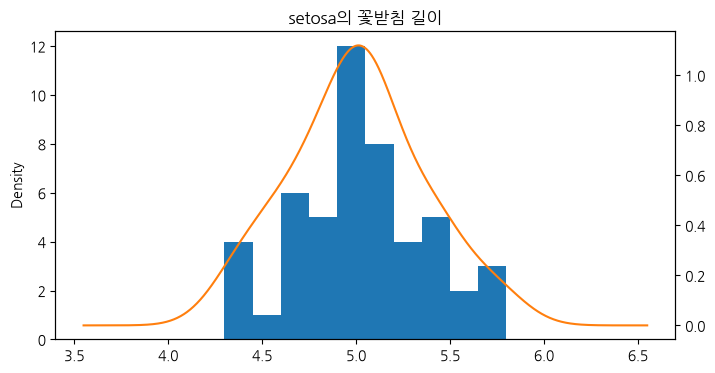

In [5]:
plt.figure(figsize=(8, 4))
setosa_df['sepal length (cm)'].plot(kind='hist')
setosa_df['sepal length (cm)'].plot(kind='kde', secondary_y=True, title='setosa의 꽃받침 길이')
plt.show()

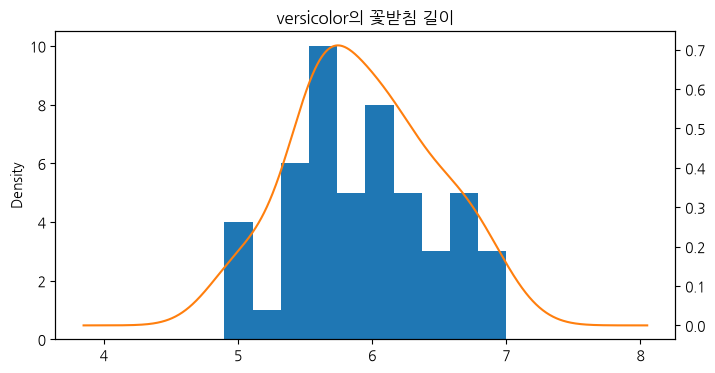

In [6]:
plt.figure(figsize=(8, 4))
versicolor_df['sepal length (cm)'].plot(kind='hist')
versicolor_df['sepal length (cm)'].plot(kind='kde', secondary_y=True, title='versicolor의 꽃받침 길이')
plt.show()

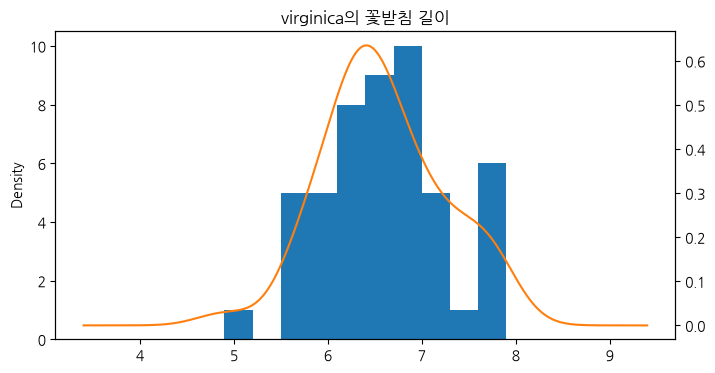

In [7]:
plt.figure(figsize=(8, 4))
virginica_df['sepal length (cm)'].plot(kind='hist')
virginica_df['sepal length (cm)'].plot(kind='kde', secondary_y=True, title='virginica의 꽃받침 길이')
plt.show()

데이터를 학습 데이터(피쳐)와 학습 데이터에 따른 관측값(레이블)으로 나눈다.

데이터프레임에 저장된 데이터를 사용할 경우  
`train, test = train_test_split(df, train_size=0.8)`  
`x_train = train[['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']]`  
`y_train = train[['target']]`  
`x_test = test[['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']]`  
`y_test = test[['target']]`

사이킷런이 제공하는 데이터셋을 사용할 경우

읽어들인 iris 데이터셋은 피쳐(dataset.data)와 레이블(dataset.target)이 별도로 존재한다.  

In [8]:
x_train, x_test, y_train, y_test = train_test_split(dataset.data, dataset.target, train_size=0.8)
print(x_train.shape, y_train.shape, x_test.shape, y_test.shape)

(120, 4) (120,) (30, 4) (30,)


가우시안 나이브 베이즈 모델을 만들고 학습시키기

In [9]:
# 가우시안 나이브 베이즈 모델을 사용하기 위해 import 한다.
from sklearn.naive_bayes import GaussianNB

In [10]:
# 가우시안 나이브 베이즈 모델을 만들고 학습시킨다.
# model = GaussianNB() # 가우시안 나이브 베이즈 모델을 만든다.
# model.fit(x_train, y_train) # 가우시안 나이브 베이즈 모델에 학습 데이터의 피쳐와 레이블을 넘겨서 학습시킨다.
model = GaussianNB().fit(x_train, y_train)

모델 테스트

In [11]:
# predict() 메소드의 인수로 테스트 데이터의 피쳐를 넘겨서 예측값을 계산한다.
predict = model.predict(x_test)
print(predict)
# accuracy_score() 함수의 인수로 테스트 데이터의 레이블(실제값)과 예측값을 넘겨서 정확도를 계산한다.
accuracy = accuracy_score(y_test, predict)
print('정확도: {:6.2%}'.format(accuracy))

[1 0 0 0 1 2 2 0 0 2 2 2 0 0 1 1 0 1 2 0 1 2 0 0 1 0 2 2 0 2]
정확도: 100.00%


In [12]:
# confusion_matrix() 함수의 인수로 테스트 데이터의 레이블(실제값)과 예측값을 넘겨서 혼동 행렬을 출력한다.
print(confusion_matrix(y_test, predict))

[[13  0  0]
 [ 0  7  0]
 [ 0  0 10]]


In [13]:
# classification_report() 함수의 인수로 테스트 데이터의 레이블(실제값)과 예측값을 넘겨서 분류 리포트를 출력한다.
print(classification_report(y_test, predict))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        13
           1       1.00      1.00      1.00         7
           2       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

